In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Cleaning data

In [3]:
cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']

In [4]:
df = pd.read_csv('1611+343_dem.txt', sep='\s+', skiprows=4, names=cols, header=None, index_col=False)
df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
0,47165.332,1.472508508776,4.937699,0.5046,1.0159,-0.003,21.0
1,47610.794,47.422934132828,7.737098,3.1809,1.6415,0.835,3.0
2,47620.338,0.554842071180,-0.460800,1.0507,1.1907,-0.022,11.0
3,47640.018,243.542065677985,-967.786099,6.7731,6.0100,-0.593,3.0
4,47655.329,2.151144023812,2.641702,0.7536,0.9041,0.061,20.0
...,...,...,...,...,...,...,...
2045,59346.229,-0.512791685462,-1.148699,0.2870,0.3626,0.093,49.0
2046,59348.271,-1.160293539259,-0.345802,0.1943,0.2444,0.385,78.0
2047,59374.251,-1.077559166964,2.305400,0.3242,0.7562,-0.161,13.0
2048,59430.248,0.144135352532,-0.896602,0.3406,0.7687,-0.240,12.0


In [5]:
df.dtypes

MJD                float64
R.A. (mas)          object
Dec. (mas)         float64
Err. R.A. (mas)    float64
Err. Dec. (mas)    float64
Corr.              float64
Del.               float64
dtype: object

In [6]:
# Convert RA to float64
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

ValueError: Unable to parse string "94.187949744281-1043.354199606483" at position 1355

In [7]:
# Examine problematic row
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,94.187949744281-1043.354199606483,0.5091,0.747,-0.24,45.0,NaN


In [8]:
# Shift data values
df.iloc[1355, :] = df.iloc[1355, :].shift()
df.iloc[1355,0] = df.iloc[1355,1]
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,53782.8,94.187949744281-1043.354199606483,0.5091,0.747,-0.24,45.0


In [9]:
df.iloc[1355,1], df.iloc[1355,2] = df.iloc[1355,2].split('-')
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,94.187949744281,1043.354199606483,0.5091,0.747,-0.24,45.0


In [10]:
# Convert RA to float64
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

In [11]:
# Convert RA to float64
df['Dec. (mas)'] = pd.to_numeric(df['Dec. (mas)'])

In [12]:
# Calculate RA*cos(dec) column
df['RAcosDEC'] = df['R.A. (mas)']*np.cos(df['Dec. (mas)'])

In [13]:
# Change to negative value
df.iloc[1355,2] *= -1 
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC
1355,53782.836,94.18795,-1043.3542,0.5091,0.747,-0.24,45.0,88.623987


In [14]:
# Change MJD to BY 
# BY=2000-(51544.333981-MJD)/365.242198781
df['BY'] = 2000-(51544.333981-df['MJD'])/365.242198781

In [15]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,47165.332,1.472509,4.937699,0.5046,1.0159,-0.003,21.0,0.328971,1988.010690
1,47610.794,47.422934,7.737098,3.1809,1.6415,0.835,3.0,5.530333,1989.230324
2,47620.338,0.554842,-0.460800,1.0507,1.1907,-0.022,11.0,0.496970,1989.256455
3,47640.018,243.542066,-967.786099,6.7731,6.0100,-0.593,3.0,239.798472,1989.310337
4,47655.329,2.151144,2.641702,0.7536,0.9041,0.061,20.0,-1.887919,1989.352257


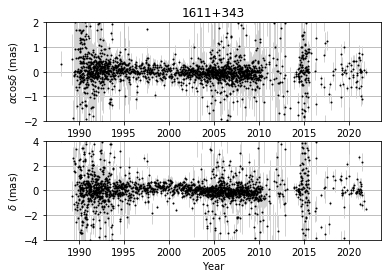

In [17]:
plt.subplot(211)
plt.title('1611+343')
plt.errorbar(df['BY'], df['RAcosDEC'],yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

# Allan Deviation

In [16]:
def allanoadev(y,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # M is the number of times we can move the averaging window from the beginning to the end
        M = N-m[k]+1

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(y[i+m[k]]-y[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [17]:
%%time
tau_dec, allanstd_dec = allanoadev(df['Dec. (mas)'].values,1)

CPU times: user 1min 43s, sys: 644 ms, total: 1min 44s
Wall time: 1min 41s


In [18]:
tau_year_dec = [x/365 for x in tau_dec]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

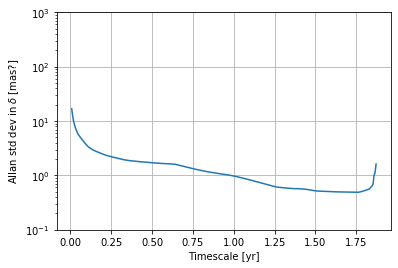

In [19]:
plt.plot(tau_year_dec,allanstd_dec)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')

In [20]:
%%time
tau_RAcosdec, allanstd_RAcosdec = allanoadev(df['RAcosDEC'].values,1)

CPU times: user 1min 44s, sys: 603 ms, total: 1min 44s
Wall time: 1min 41s


In [21]:
tau_year_RAcosdec = [x/365 for x in tau_RAcosdec]

Text(0, 0.5, 'Allan std dev in acos$\\delta$ [mas?]')

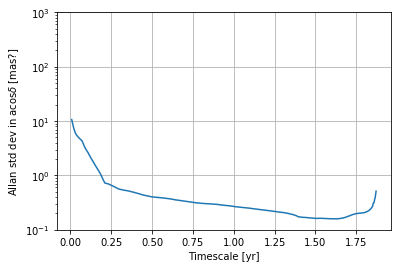

In [22]:
plt.plot(tau_year_RAcosdec,allanstd_RAcosdec)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in acos$\delta$ [mas?]')

# Using weighted mean

In [18]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,47165.332,1.472509,4.937699,0.5046,1.0159,-0.003,21.0,0.328971,1988.010690
1,47610.794,47.422934,7.737098,3.1809,1.6415,0.835,3.0,5.530333,1989.230324
2,47620.338,0.554842,-0.460800,1.0507,1.1907,-0.022,11.0,0.496970,1989.256455
3,47640.018,243.542066,-967.786099,6.7731,6.0100,-0.593,3.0,239.798472,1989.310337
4,47655.329,2.151144,2.641702,0.7536,0.9041,0.061,20.0,-1.887919,1989.352257


In [19]:
# Create function to create merged dataframe
def get_ideal(df):
    # Start and end date
    start_date = math.trunc(df['MJD'].min())
    end_date = math.trunc(df['MJD'].max())
    
    # Array of daily dates 
    real_dates = np.arange(start_date,1+end_date,1)
    
    # Dataframe from daily dates array
    dates_df = pd.DataFrame(real_dates, columns=['MJDReal'])
    
    # Truncate the MJD column in df 
    df['MJDtrunc'] = df['MJD'].apply(math.trunc)

    # Right merge
    merge_df = df.merge(dates_df, how='right',left_on='MJDtrunc',right_on='MJDReal')
    
    # Sort merge_df
    merge_df = merge_df.sort_values(by=['MJDReal'])

    # Fill NaN values
    merge_df = merge_df.fillna(0)
    
    return merge_df, real_dates

In [22]:
ideal_df, dates = get_ideal(df)

In [24]:
ideal_df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY,MJDtrunc,MJDReal
0,47165.332,1.472509,4.937699,0.5046,1.0159,-0.003,21.0,0.328971,1988.010690,47165.0,47165
2050,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47166
2051,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47167
2052,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47168
2053,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47169
...,...,...,...,...,...,...,...,...,...,...,...
12402,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,59503
12403,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,59504
12404,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,59505
12405,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,59506


In [25]:
def allanoadev_D_WMA(y,dates,error,rate):
        
    # === Parameters ===
    
    # Length of observation
    start_date = dates.min()
    end_date = dates.max()
    N = end_date - start_date
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Create weights 
    weights_std = []
    for val in error:
        if val != 0:
            weights_std.append(1/(val**2))
        elif val == 0:
            weights_std.append(0)

    # Iterate over values of m
    for k in range(len(m)): 
        print('Current value of m: ', m[k])
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []
        D = 0
        data_sum = 0
        
        # Check for missing windows 
        while right <= N:
            data_values = y[left:right]
            data_sum = np.sum(data_values)
    
            if data_sum == 0:
                D +=1
            else:
                avg = np.average(data_values, weights=weights_std[left:right])
                ybar.append(avg)
            left += step 
            right += step    
            

        M_D = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M_D-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i]) #weighted mean, bikin error sendiri - dist gaussian
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M_D-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [26]:
%%time
tau_D, allanstd_D = allanoadev_D_WMA(ideal_df['Dec. (mas)'].values,ideal_df['MJDReal'].values,ideal_df['Err. Dec. (mas)'].values,1)

Current value of m:  3
Current value of m:  4
Current value of m:  5
Current value of m:  6
Current value of m:  7
Current value of m:  8
Current value of m:  9
Current value of m:  10
Current value of m:  11
Current value of m:  12
Current value of m:  13
Current value of m:  14
Current value of m:  15
Current value of m:  16
Current value of m:  17
Current value of m:  18
Current value of m:  19
Current value of m:  20
Current value of m:  21
Current value of m:  22
Current value of m:  23
Current value of m:  24
Current value of m:  25
Current value of m:  26
Current value of m:  27
Current value of m:  28
Current value of m:  29
Current value of m:  30
Current value of m:  31
Current value of m:  32
Current value of m:  33
Current value of m:  34
Current value of m:  35
Current value of m:  36
Current value of m:  37
Current value of m:  38
Current value of m:  39
Current value of m:  40
Current value of m:  41
Current value of m:  42
Current value of m:  43
Current value of m:  44

In [27]:
tau_year_D = [x/365.242198781 for x in tau_D]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

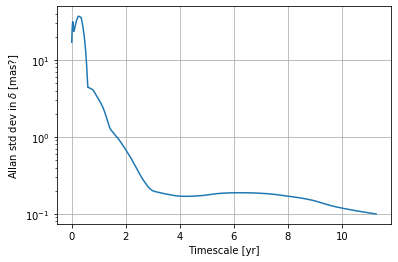

In [28]:
plt.plot(tau_year_D, allanstd_D)
plt.yscale('log')
# plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')

In [29]:
%%time
tau_RA_D, allanstd_RA_D = allanoadev_D_WMA(ideal_df['RAcosDEC'].values,ideal_df['MJDReal'].values,ideal_df['Err. R.A. (mas)'].values,1)

Current value of m:  3
Current value of m:  4
Current value of m:  5
Current value of m:  6
Current value of m:  7
Current value of m:  8
Current value of m:  9
Current value of m:  10
Current value of m:  11
Current value of m:  12
Current value of m:  13
Current value of m:  14
Current value of m:  15
Current value of m:  16
Current value of m:  17
Current value of m:  18
Current value of m:  19
Current value of m:  20
Current value of m:  21
Current value of m:  22
Current value of m:  23
Current value of m:  24
Current value of m:  25
Current value of m:  26
Current value of m:  27
Current value of m:  28
Current value of m:  29
Current value of m:  30
Current value of m:  31
Current value of m:  32
Current value of m:  33
Current value of m:  34
Current value of m:  35
Current value of m:  36
Current value of m:  37
Current value of m:  38
Current value of m:  39
Current value of m:  40
Current value of m:  41
Current value of m:  42
Current value of m:  43
Current value of m:  44

In [30]:
tau_year_RA_D = [x/365.242198781 for x in tau_RA_D]

Text(0, 0.5, 'Allan std dev in $\\alpha\\cos{\\delta}$ [mas?]')

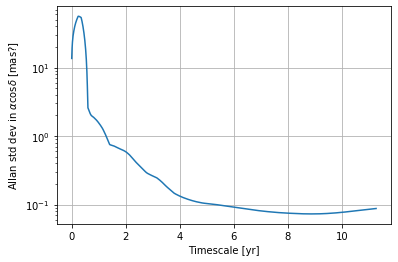

In [31]:
plt.plot(tau_year_RA_D, allanstd_RA_D)
plt.yscale('log')
# plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel(r'Allan std dev in $\alpha\cos{\delta}$ [mas?]')